In [2]:
!pip install -q ultralytics roboflow
!pip install -q git+https://github.com/roboflow/sports.git

import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO, settings
from sports.configs.soccer import SoccerPitchConfiguration

settings.update({'raytune': False})

  Preparing metadata (setup.py) ... done


In [ ]:
RETRAIN = False

if RETRAIN:
    from kaggle_secrets import UserSecretsClient
    from roboflow import Roboflow

    rf = Roboflow(api_key=UserSecretsClient().get_secret("ROBOFLOW_API_KEY"))
    dataset = (rf.workspace("roboflow-jvuqo")
                 .project("football-field-detection-f07vi")
                 .version(14)
                 .download("yolov8"))

    pose = YOLO('yolov8x-pose.pt')
    metrics = pose.train(data=f"{dataset.location}/data.yaml", epochs=100, batch=8,
                         mosaic=0.0, name='pitch_keypoints')
    print(f"keypoint mAP50-95: {metrics.pose.map:.3f} | box mAP50-95: {metrics.box.map:.3f}")

In [10]:
cfg = SoccerPitchConfiguration(
    width=6800, length=10500,
    penalty_box_width=4032, penalty_box_length=1650,
    goal_box_width=1832, goal_box_length=550,
    centre_circle_radius=915, penalty_spot_distance=1100,
)
PITCH_VERTICES = np.array(cfg.vertices, dtype=np.float32) / 100.0
assert np.allclose(PITCH_VERTICES.max(axis=0), [105.0, 68.0])

POSE_WEIGHTS = '/kaggle/input/models/yanisg/pitch-keypoints/pytorch/default/1/best.pt'
pitch_model = YOLO(POSE_WEIGHTS)

class PitchCalibrator:
    def __init__(self, model, vertices, conf_min=0.5, refresh=3, alpha=0.4,
                 max_err=2.0, ransac_thresh=2.0, max_jump=25.0):
        self.model = model
        self.vertices = vertices
        self.conf_min = conf_min
        self.refresh = refresh
        self.alpha = alpha
        self.max_err = max_err
        self.ransac_thresh = ransac_thresh
        self.max_jump = max_jump
        self.H = None
        self.i = 0

    def keypoints(self, frame):
        result = self.model(frame, verbose=False)[0]
        if result.keypoints is None or len(result.keypoints.xy) == 0:
            return None
        kp = result.keypoints.xy[0].cpu().numpy()
        conf = result.keypoints.conf[0].cpu().numpy()
        mask = conf > self.conf_min
        if mask.sum() < 5:
            return None
        return kp[mask].astype(np.float32), self.vertices[mask]

    @staticmethod
    def center_on_pitch(H, frame):
        h, w = frame.shape[:2]
        pt = np.array([[[w / 2, h / 2]]], dtype=np.float32)
        return cv2.perspectiveTransform(pt, H)[0][0]

    def estimate(self, frame):
        pts = self.keypoints(frame)
        if pts is None:
            return None
        src, dst = pts
        H_new, inliers = cv2.findHomography(src, dst, cv2.RANSAC, self.ransac_thresh)
        if H_new is None or inliers.sum() < 5:
            return None
        proj = cv2.perspectiveTransform(src.reshape(-1, 1, 2), H_new).reshape(-1, 2)
        err = np.linalg.norm(proj - dst, axis=1)[inliers.ravel() == 1].mean()
        if err > self.max_err:
            return None
        cx, cy = self.center_on_pitch(H_new, frame)
        if not (-10 <= cx <= 115 and -10 <= cy <= 78):
            return None
        return H_new / H_new[2, 2]

    def update(self, frame):
        if self.i % self.refresh == 0:
            H_new = self.estimate(frame)
            if H_new is not None:
                if self.H is None:
                    self.H = H_new
                else:
                    jump = np.linalg.norm(self.center_on_pitch(H_new, frame)
                                          - self.center_on_pitch(self.H, frame))
                    if jump > self.max_jump:
                        self.H = H_new
                    else:
                        self.H = self.alpha * H_new + (1 - self.alpha) * self.H
                        self.H = self.H / self.H[2, 2]
        self.i += 1
        return self.H

In [11]:
import random
import torch

base = '/kaggle/input/datasets/saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv'
clips_all = sorted(glob.glob(base + '/**/*.mp4', recursive=True))
random.seed(42)
sample = random.sample(clips_all, 100)

def clip_coverage(path, n_samples=5):
    cap = cv2.VideoCapture(path)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    probe = PitchCalibrator(pitch_model, PITCH_VERTICES)
    valid = []
    for idx in np.linspace(0, n - 1, n_samples).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            valid.append(probe.estimate(frame) is not None)
    cap.release()
    return valid

coverage = [v for v in (clip_coverage(p) for p in tqdm(sample)) if v]
first_frame = np.mean([v[0] for v in coverage])
half_frames = np.mean([np.mean(v) >= 0.5 for v in coverage])
all_frames = np.mean([np.mean(v) for v in coverage])

print(f"first frame calibrated   : {first_frame:.1%}")
print(f"clips with >=50% frames  : {half_frames:.1%}")
print(f"mean fraction of frames  : {all_frames:.1%}")


100%|██████████| 100/100 [04:02<00:00,  2.43s/it]

first frame calibrated   : 82.0%
clips with >=50% frames  : 82.0%
mean fraction of frames  : 79.8%


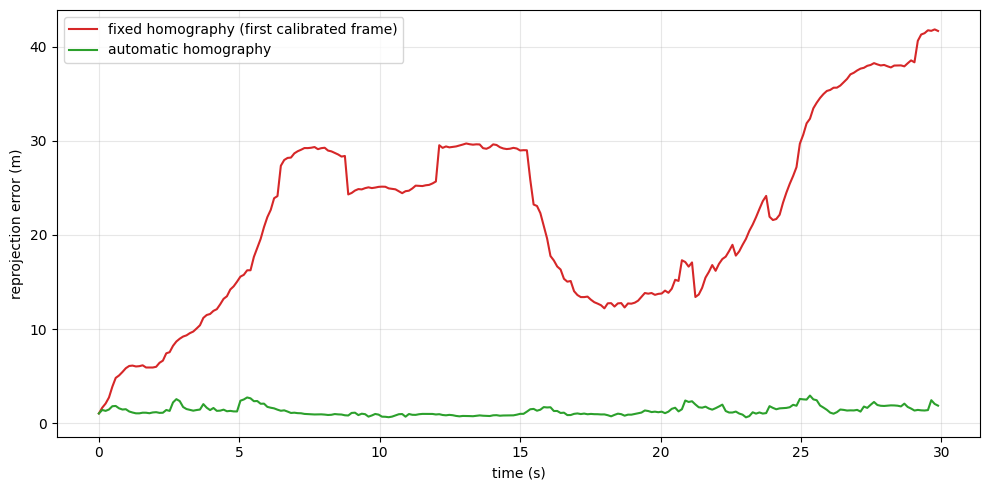

mean error  fixed: 22.15 m | auto: 1.32 m
max error   fixed: 41.85 m | auto: 2.93 m


In [13]:
CLIP_PATH = [p for p in clips_all if 'B1606b0e6_1 (42)' in p][0]

cap = cv2.VideoCapture(CLIP_PATH)
fps = int(cap.get(cv2.CAP_PROP_FPS))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
calibrator = PitchCalibrator(pitch_model, PITCH_VERTICES)

H_static = None
times, err_static, err_auto = [], [], []

for i in range(n_frames):
    ret, frame = cap.read()
    if not ret:
        break
    H_auto = calibrator.update(frame)
    if H_auto is None:
        continue
    if H_static is None:
        H_static = H_auto.copy()
    if i % 3 != 0:
        continue
    pts = calibrator.keypoints(frame)
    if pts is None:
        continue
    src, dst = pts
    errors = []
    for H_use in (H_static, H_auto):
        proj = cv2.perspectiveTransform(src.reshape(-1, 1, 2), H_use).reshape(-1, 2)
        errors.append(np.median(np.linalg.norm(proj - dst, axis=1)))
    err_static.append(errors[0])
    err_auto.append(errors[1])
    times.append(i / fps)
cap.release()

plt.figure(figsize=(10, 5))
plt.plot(times, err_static, label='fixed homography (first calibrated frame)', color='tab:red')
plt.plot(times, err_auto, label='automatic homography', color='tab:green')
plt.xlabel('time (s)')
plt.ylabel('reprojection error (m)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/reprojection_error.png', dpi=150)
plt.show()

print(f"mean error  fixed: {np.mean(err_static):.2f} m | auto: {np.mean(err_auto):.2f} m")
print(f"max error   fixed: {np.max(err_static):.2f} m | auto: {np.max(err_auto):.2f} m")